# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [8]:
# Import essential libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
import sklearn

print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("seaborn version:", sns.__version__)
print("matplotlib version:", matplotlib.__version__)
print("tensorflow version:", tf.__version__)
print("keras version:", keras.__version__)
print("sklearn version:", sklearn.__version__)

numpy version: 2.2.6
pandas version: 2.3.3
seaborn version: 0.13.2
matplotlib version: 3.10.8
tensorflow version: 2.21.0
keras version: 3.12.2
sklearn version: 1.7.2


Load the dataset.

In [1]:
# Load and unzip the dataset

import zipfile
import os
import shutil

if not os.path.exists("data"):
    with zipfile.ZipFile("Dataset_Waste_Segregation.zip", 'r') as z:
        z.extractall("_temp")

    with zipfile.ZipFile("_temp/Dataset_Waste_Segregation/Dataset_Waste_Segregation/data.zip", 'r') as z:
        z.extractall(".")

    shutil.rmtree("_temp")
    print("Dataset extracted to 'data/'")
else:
    print("'data/' already exists — skipping extraction")

print(os.listdir("data"))

'data/' already exists — skipping extraction
['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [5]:
# Create a function to load the raw images
from PIL import Image

def load_image(image_path):
    """
    Loads a single image from the given path as a PIL Image object.
    Converts to RGB to ensure consistent channel format
    (some images may be grayscale or have an alpha channel).
    """
    img = Image.open(image_path).convert("RGB")
    return img

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [6]:
# Get the images and their labels

data_dir = "data"
class_names = sorted(os.listdir(data_dir))

images = []
labels = []

for class_name in class_names:
    class_folder = os.path.join(data_dir, class_name)
    for filename in os.listdir(class_folder):
        image_path = os.path.join(class_folder, filename)
        img = load_image(image_path)
        images.append(img)
        labels.append(class_name)

print(f"Total images loaded: {len(images)}")
print(f"Total labels loaded: {len(labels)}")

Total images loaded: 7625
Total labels loaded: 7625


Perform any operations, if needed, on the images and labels to get them into the desired format.

In [ ]:
# No additional formatting needed at this stage —
# images are RGB PIL Images, labels are class-name strings.
# Resizing and array conversion happen in 2.2.3; label encoding in 2.3.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

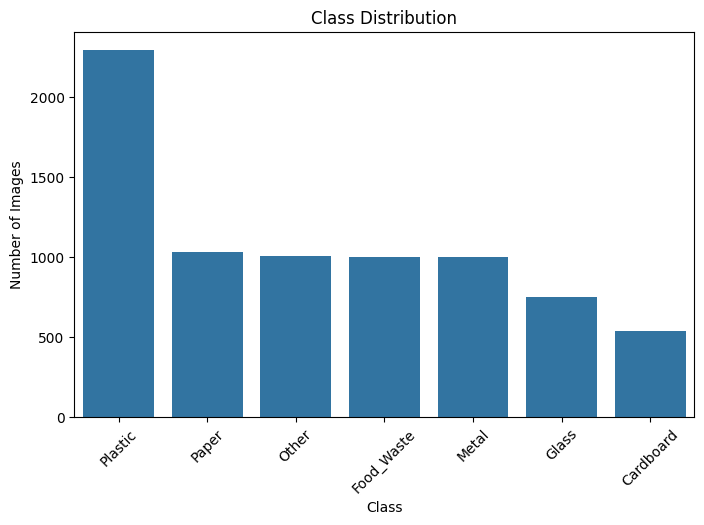

In [9]:
# Visualise Data Distribution

label_counts = pd.Series(labels).value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

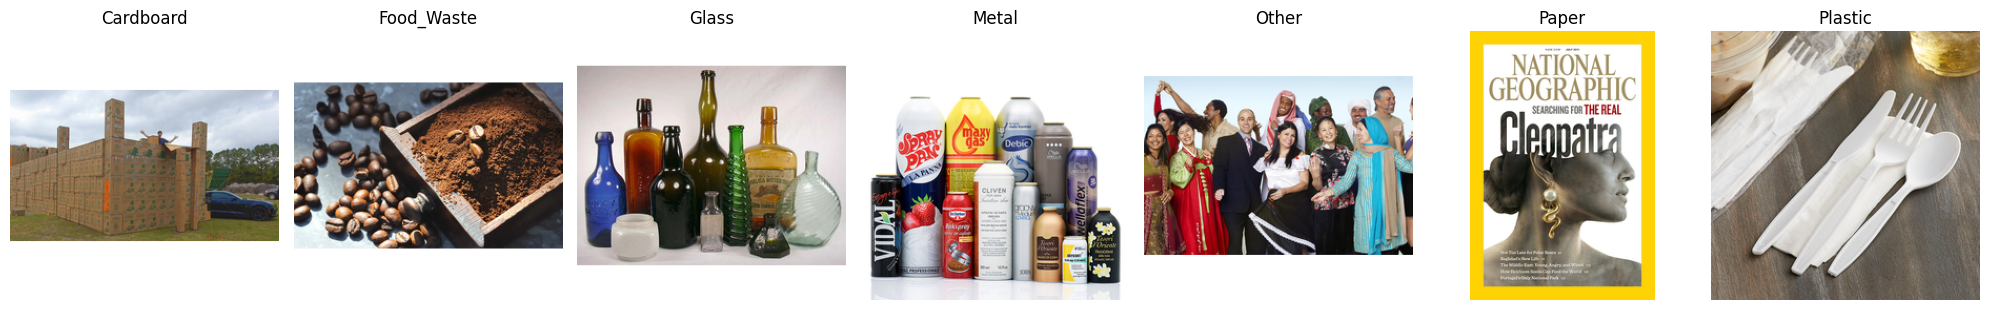

In [10]:
# Visualise Sample Images (across different labels)

fig, axes = plt.subplots(1, len(class_names), figsize=(20, 4))

for ax, class_name in zip(axes, class_names):
    idx = labels.index(class_name)
    ax.imshow(images[idx])
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [11]:
# Find the smallest and largest image dimensions from the data set

widths = [img.size[0] for img in images]
heights = [img.size[1] for img in images]

print("Smallest width:", min(widths), " | Largest width:", max(widths))
print("Smallest height:", min(heights), " | Largest height:", max(heights))

Smallest width: 256  | Largest width: 256
Smallest height: 256  | Largest height: 256


In [12]:
# Resize the image dimensions

# All images are already uniformly 256x256 (confirmed above: min = max for both
# width and height), so no resizing is necessary at this stage.
# We'll standardize on 256x256 as the target size going forward.

IMG_SIZE = (256, 256)
print(f"All images are already {IMG_SIZE[0]}x{IMG_SIZE[1]} — no resize needed.")

All images are already 256x256 — no resize needed.


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [ ]:
# Encode the labels suitably



### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [ ]:
# Assign specified parts of the dataset to train and validation sets



## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [ ]:
# Build and compile the model



#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [ ]:
# Training



### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

In [ ]:
# Evaluate on the test set; display suitable metrics



## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# Define augmentation steps to augment images



Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images




In [ ]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results